# Notebook 2.3 — Refined PPO Training (`VecNormalize`) & Portfolio Backtest

**Purpose:** Train an optimized PPO agent using **`VecNormalize`**, **scaled rewards**, and **reduced entropy (`ent_coef = 0.005`)**, then evaluate performance against Equal-Weight and Buy-and-Hold benchmarks (2020-present).

## Refinements Applied

1. **Observation & Reward Normalization (`VecNormalize`)**: Standardizes 65-dim observation inputs and dynamically normalizes reward signals.
2. **Re-scaled Reward Signal**: Daily returns are scaled by $100$ ($R_{\text{return}} = 100 \cdot r_t$), while penalties are reduced ($\lambda_{dd} = 0.02, \gamma_{to} = 0.0005$).
3. **Exploitation Tuning**: Reduced `ent_coef` from $0.05$ to $0.005$ and set constant learning rate `3e-4` with network `[256, 256]`.

In [1]:
# CELL 1: IMPORTS
import os
import time
import pickle
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mtick

import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize

print("Cell 1 done: imports loaded.")
try:
    from stable_baselines3 import __version__ as sb3_ver
    print(f"  stable-baselines3 : {sb3_ver}")
except Exception:
    pass
print(f"  gymnasium         : {gym.__version__}")

Cell 1 done: imports loaded.
  stable-baselines3 : 2.9.0
  gymnasium         : 1.3.0


In [2]:
# CELL 2: CONFIGURATION
TICKERS = ['HDFCBANK.NS', 'NVDA', 'RELIANCE.NS', 'TCS.NS']
N_ASSETS = len(TICKERS)
N_ACT    = N_ASSETS + 1

FEATURE_COLS = [
    'Log_Ret',   'Vol_20',    'Vol_Ratio',
    'Ret_1M',    'Ret_3M',    'Efficiency', 'Vol_Shock',
    'Ret_Lag1',  'Ret_Lag2',  'Ret_Lag3',
    'Ret_Lag5',  'Ret_Lag10', 'Ret_Lag20',
    'Sentiment', 'Phase1_Signal',
]
N_FEAT_PER_ASSET = len(FEATURE_COLS)
N_OBS_FEAT       = N_ASSETS * N_FEAT_PER_ASSET
OBS_DIM          = N_OBS_FEAT + N_ACT

INITIAL_BALANCE  = 100_000.0
TRANSACTION_COST = 0.001
REWARD_SCALE     = 100.0
LAMBDA_DD        = 0.02
GAMMA_TO         = 0.0005

TRAIN_END   = "2019-12-31"   # 2011-2019 training split
TEST_START  = "2020-01-01"   # 2020-present test split

TOTAL_TIMESTEPS = 500_000
SEED            = 42

_in_nb_dir  = os.path.basename(os.getcwd()) == "notebooks"
DATA_DIR    = "../data"            if _in_nb_dir else "data"
ART_DIR     = "../model_artifacts" if _in_nb_dir else "model_artifacts"
DATA_PATH   = os.path.join(DATA_DIR, "enriched_rl_data.csv")
MODEL_PATH  = os.path.join(ART_DIR, "ppo_multi_asset_v2")
VEC_NORM_PATH = os.path.join(ART_DIR, "vec_normalize.pkl")

print("Cell 2 done: Configuration loaded.")
print(f"  Training period  : 2011-01-01 -> {TRAIN_END}")
print(f"  Test period      : {TEST_START} -> present")
print(f"  Total timesteps  : {TOTAL_TIMESTEPS:,}")
print(f"  Reward Scale     : {REWARD_SCALE}x")
print(f"  lambda (drawdown): {LAMBDA_DD}")
print(f"  gamma  (turnover): {GAMMA_TO}")

Cell 2 done: Configuration loaded.
  Training period  : 2011-01-01 -> 2019-12-31
  Test period      : 2020-01-01 -> present
  Total timesteps  : 500,000
  Reward Scale     : 100.0x
  lambda (drawdown): 0.02
  gamma  (turnover): 0.0005


In [3]:
# CELL 3: LOAD DATA & TRAIN/TEST SPLIT
raw_df = pd.read_csv(DATA_PATH, index_col="Date", parse_dates=True)
raw_df.sort_index(inplace=True)
raw_df.dropna(inplace=True)

feat_pivot = (
    raw_df[FEATURE_COLS + ['Ticker']]
    .reset_index()
    .pivot_table(index='Date', columns='Ticker', values=FEATURE_COLS, aggfunc='first')
)
feat_pivot = feat_pivot.swaplevel(axis=1).sort_index(axis=1)
feat_pivot.dropna(inplace=True)

LOG_RET_INDICES = [i for i, (t, f) in enumerate(feat_pivot.columns) if f == 'Log_Ret']
feat_pivot.columns = [f"{t}__{f}" for t, f in feat_pivot.columns]

price_pivot = (
    raw_df[['Ticker', 'Close_Price']]
    .reset_index()
    .pivot_table(index='Date', columns='Ticker', values='Close_Price', aggfunc='first')
    [TICKERS]
    .loc[feat_pivot.index]
)

train_pivot = feat_pivot[feat_pivot.index <= TRAIN_END]
test_pivot  = feat_pivot[feat_pivot.index >= TEST_START]

train_feat_arr = train_pivot.values.astype(np.float32)
test_feat_arr  = test_pivot.values.astype(np.float32)

print(f"Cell 3 done: Data split complete.")
print(f"  Train split : {train_pivot.shape}")
print(f"  Test split  : {test_pivot.shape}")

Cell 3 done: Data split complete.
  Train split : (2137, 60)
  Test split  : (1583, 60)


In [4]:
# CELL 4: MultiAssetGenWealthEnv INLINE DEFINITION
class MultiAssetGenWealthEnv(gym.Env):
    metadata = {"render_modes": ["human"]}

    def __init__(
        self,
        feat_array,
        log_ret_indices,
        n_assets=4,
        initial_balance=100_000.0,
        transaction_cost=0.001,
        reward_scale=100.0,
        lambda_dd=0.02,
        gamma_to=0.0005,
    ):
        super().__init__()
        self.feat_array      = np.asarray(feat_array, dtype=np.float32)
        self.log_ret_indices = np.asarray(log_ret_indices, dtype=np.int32)
        self.n_assets        = n_assets
        self.n_act           = n_assets + 1
        self.n_steps         = len(feat_array)
        self.initial_balance = float(initial_balance)
        self.tc              = float(transaction_cost)
        self.reward_scale    = float(reward_scale)
        self.lambda_dd       = float(lambda_dd)
        self.gamma_to        = float(gamma_to)

        self.action_space = spaces.Box(low=-3.0, high=3.0, shape=(self.n_act,), dtype=np.float32)
        obs_dim = self.feat_array.shape[1] + self.n_act
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(obs_dim,), dtype=np.float32)

        self.current_step    = 0
        self.portfolio_value = self.initial_balance
        self.current_weights = np.zeros(self.n_act, dtype=np.float32)
        self.peak_value      = self.initial_balance
        self.portfolio_values = []
        self.weight_history  = []

    def _softmax(self, logits):
        x = np.asarray(logits, dtype=np.float64)
        e = np.exp(x - x.max())
        return (e / e.sum()).astype(np.float32)

    def _get_obs(self):
        features = self.feat_array[self.current_step]
        return np.concatenate([features, self.current_weights], dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step    = 0
        self.portfolio_value = self.initial_balance
        self.peak_value      = self.initial_balance
        self.current_weights = np.array([0.0] * self.n_assets + [1.0], dtype=np.float32)
        self.portfolio_values = [self.initial_balance]
        self.weight_history  = [self.current_weights.copy()]
        return self._get_obs(), {}

    def step(self, action):
        logits         = np.clip(action, -3.0, 3.0)
        target_weights = self._softmax(logits)
        turnover       = float(np.sum(np.abs(target_weights - self.current_weights)))
        cost           = turnover * self.portfolio_value * self.tc
        self.portfolio_value -= cost

        next_step = self.current_step + 1
        if next_step >= self.n_steps:
            next_step = self.n_steps - 1

        asset_log_rets    = self.feat_array[next_step][self.log_ret_indices]
        asset_simple_rets = np.exp(asset_log_rets.astype(np.float64)) - 1.0
        stock_weights     = target_weights[:self.n_assets].astype(np.float64)
        port_return       = float(np.dot(stock_weights, asset_simple_rets))

        self.portfolio_value = max(self.portfolio_value * (1.0 + port_return), 1.0)
        self.peak_value      = max(self.peak_value, self.portfolio_value)
        drawdown             = (self.peak_value - self.portfolio_value) / (self.peak_value + 1e-9)

        reward = (
            self.reward_scale * port_return
            - self.lambda_dd * drawdown
            - self.gamma_to  * turnover
        )

        self.current_weights = target_weights
        self.current_step    = next_step
        self.portfolio_values.append(self.portfolio_value)
        self.weight_history.append(target_weights.copy())

        terminated = (self.current_step >= self.n_steps - 1)
        info = {
            "portfolio_value": self.portfolio_value,
            "weights"        : target_weights,
            "turnover"       : turnover,
            "drawdown"       : drawdown,
            "port_return"    : port_return,
        }
        return self._get_obs(), float(reward), terminated, False, info

print("Cell 4 done: MultiAssetGenWealthEnv (inline copy) defined.")

Cell 4 done: MultiAssetGenWealthEnv (inline copy) defined.


In [5]:
# CELL 5: VECNORMALIZE WRAPPER SETUP
env_kwargs = dict(
    log_ret_indices  = LOG_RET_INDICES,
    n_assets         = N_ASSETS,
    initial_balance  = INITIAL_BALANCE,
    transaction_cost = TRANSACTION_COST,
    reward_scale     = REWARD_SCALE,
    lambda_dd        = LAMBDA_DD,
    gamma_to         = GAMMA_TO,
)

def make_train_env():
    return Monitor(MultiAssetGenWealthEnv(train_feat_arr, **env_kwargs))

train_vec_env = DummyVecEnv([make_train_env])
train_vec_env = VecNormalize(
    train_vec_env,
    norm_obs=True,
    norm_reward=True,
    clip_obs=10.0,
    clip_reward=10.0,
    gamma=0.99
)

print("Cell 5 done: Training VecNormalize environment ready.")
print(f"  Normalized Obs Shape    : {train_vec_env.observation_space.shape}")
print(f"  Normalized Reward active: {train_vec_env.norm_reward}")

Cell 5 done: Training VecNormalize environment ready.
  Normalized Obs Shape    : (65,)
  Normalized Reward active: True


In [6]:
# CELL 6: PPO INITIALIZATION WITH REFINED HYPERPARAMETERS
def linear_schedule(initial_lr: float, final_lr: float = 3e-5):
    def schedule(progress_remaining: float) -> float:
        return final_lr + progress_remaining * (initial_lr - final_lr)
    return schedule

model = PPO(
    "MlpPolicy",
    train_vec_env,
    verbose=1,
    seed=SEED,
    learning_rate = linear_schedule(3e-4, 3e-5),
    n_steps       = 2048,
    batch_size    = 128,
    n_epochs      = 10,
    gamma         = 0.99,
    gae_lambda    = 0.95,
    clip_range    = 0.2,
    ent_coef      = 0.005,
    vf_coef       = 0.5,
    max_grad_norm = 0.5,
    policy_kwargs = dict(net_arch=[256, 256]),
    tensorboard_log = None,
)

print("Cell 6 done: Refined PPO agent initialized.")
print("  Learning Rate : Linear Schedule (3e-4 -> 3e-5)")
print("  Entropy Coef  : 0.005")
print("  Architecture  : [256, 256]")

Using cpu device
Cell 6 done: Refined PPO agent initialized.
  Learning Rate : Linear Schedule (3e-4 -> 3e-5)
  Entropy Coef  : 0.005
  Architecture  : [256, 256]


In [7]:
# CELL 7: TRAINING CALLBACK
class PortfolioTrainingCallback(BaseCallback):
    def __init__(self, log_every: int = 10_000, verbose: int = 0):
        super().__init__(verbose)
        self.log_every      = log_every
        self._last_log_step = 0
        self.reward_history = []

    def _on_step(self) -> bool:
        if self.num_timesteps - self._last_log_step >= self.log_every:
            self._last_log_step = self.num_timesteps
            ep_info = self.model.ep_info_buffer
            if len(ep_info) > 0:
                ep_rew_mean = float(np.mean([ep['r'] for ep in ep_info]))
                ep_len_mean = float(np.mean([ep['l'] for ep in ep_info]))
                self.reward_history.append(ep_rew_mean)
                progress_pct = 100.0 * self.num_timesteps / TOTAL_TIMESTEPS
                print(
                    f"  [{self.num_timesteps:>7,}/{TOTAL_TIMESTEPS:,}]  "
                    f"ep_rew_mean={ep_rew_mean:+9.4f}  "
                    f"ep_len={ep_len_mean:.0f}  "
                    f"done={progress_pct:.1f}%"
                )
        return True

callback = PortfolioTrainingCallback(log_every=10_000)
print("Cell 7 done: Callback ready.")

Cell 7 done: Callback ready.


In [8]:
# CELL 8: PPO TRAINING (500,000 TIMESTEPS)
print(f"Starting PPO training: {TOTAL_TIMESTEPS:,} timesteps")
print("-" * 75)
t0 = time.time()

model.learn(
    total_timesteps     = TOTAL_TIMESTEPS,
    callback            = callback,
    reset_num_timesteps = True,
    progress_bar        = False,
)

elapsed = time.time() - t0
print("-" * 75)
print(f"Training complete in {elapsed/60:.1f} minutes ({elapsed:.0f}s)")

Starting PPO training: 500,000 timesteps
---------------------------------------------------------------------------
-----------------------------
| time/              |      |
|    fps             | 1139 |
|    iterations      | 1    |
|    time_elapsed    | 1    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 2.14e+03    |
|    ep_rew_mean          | 134         |
| time/                   |             |
|    fps                  | 942         |
|    iterations           | 2           |
|    time_elapsed         | 4           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.022130778 |
|    clip_fraction        | 0.208       |
|    clip_range           | 0.2         |
|    entropy_loss         | -7.09       |
|    explained_variance   | -0.273      |
|    learning_rate        | 0.000299    |
|

In [9]:
# CELL 9: SAVE MODEL & VECNORMALIZE STATS
os.makedirs(ART_DIR, exist_ok=True)
model.save(MODEL_PATH)
train_vec_env.save(VEC_NORM_PATH)
print(f"Cell 9 done: Model saved to {MODEL_PATH}.zip and VecNormalize stats to {VEC_NORM_PATH}")

Cell 9 done: Model saved to ../model_artifacts\ppo_multi_asset_v2.zip and VecNormalize stats to ../model_artifacts\vec_normalize.pkl


In [10]:
# CELL 10: EVALUATION BACKTEST ON UNSEEN DATA (2020-PRESENT)
print(f"Running PPO evaluation backtest: {TEST_START} -> present")

def make_test_env():
    return MultiAssetGenWealthEnv(test_feat_arr, **env_kwargs)

eval_vec_env = DummyVecEnv([make_test_env])
eval_vec_env = VecNormalize.load(VEC_NORM_PATH, eval_vec_env)
eval_vec_env.training = False
eval_vec_env.norm_reward = False

raw_test_env = eval_vec_env.venv.envs[0]
model_loaded = PPO.load(MODEL_PATH)

obs = eval_vec_env.reset()
done = False
rl_portfolio = [raw_test_env.portfolio_values[0]]
rl_weights_history = [raw_test_env.current_weights.copy()]

while not done:
    action, _ = model_loaded.predict(obs, deterministic=True)
    obs, reward, done_vec, info_vec = eval_vec_env.step(action)
    rl_portfolio.append(info_vec[0]["portfolio_value"])
    rl_weights_history.append(info_vec[0]["weights"].copy())
    done = done_vec[0]

rl_portfolio = np.array(rl_portfolio)
rl_weights   = np.array(rl_weights_history)

print(f"Backtest complete: {len(rl_portfolio)} days")
print(f"  RL Agent final value : {rl_portfolio[-1]:>12,.0f} ({(rl_portfolio[-1]/INITIAL_BALANCE-1)*100:+.1f}%)")

Running PPO evaluation backtest: 2020-01-01 -> present
Backtest complete: 1583 days
  RL Agent final value :      208,683 (+108.7%)


In [11]:
# CELL 11: EQUAL-WEIGHT & BUY-AND-HOLD BENCHMARKS
T_test = len(test_feat_arr)

eq_portfolio = [INITIAL_BALANCE]
for t in range(1, T_test):
    asset_log_rets = test_feat_arr[t][LOG_RET_INDICES]
    asset_rets     = np.exp(asset_log_rets.astype(np.float64)) - 1.0
    daily_ret      = float(asset_rets.mean())
    eq_portfolio.append(eq_portfolio[-1] * (1.0 + daily_ret))
eq_portfolio = np.array(eq_portfolio)

bnh_portfolio = [INITIAL_BALANCE]
bnh_weights   = np.array([1.0 / N_ASSETS] * N_ASSETS)
for t in range(1, T_test):
    asset_log_rets = test_feat_arr[t][LOG_RET_INDICES]
    asset_rets     = np.exp(asset_log_rets.astype(np.float64)) - 1.0
    daily_ret      = float(np.dot(bnh_weights, asset_rets))
    new_val        = bnh_portfolio[-1] * (1.0 + daily_ret)
    bnh_portfolio.append(new_val)
    bnh_weights    = bnh_weights * (1.0 + asset_rets)
    bnh_weights    = bnh_weights / (bnh_weights.sum() + 1e-9)
bnh_portfolio = np.array(bnh_portfolio)

print("Cell 11 done: Benchmarks constructed.")
print(f"  Equal-Weight final : {eq_portfolio[-1]:>12,.0f} ({(eq_portfolio[-1]/INITIAL_BALANCE-1)*100:+.1f}%)")
print(f"  Buy-and-Hold final : {bnh_portfolio[-1]:>12,.0f} ({(bnh_portfolio[-1]/INITIAL_BALANCE-1)*100:+.1f}%)")
print(f"  RL Agent final     : {rl_portfolio[-1]:>12,.0f} ({(rl_portfolio[-1]/INITIAL_BALANCE-1)*100:+.1f}%)")

Cell 11 done: Benchmarks constructed.
  Equal-Weight final :      353,958 (+254.0%)
  Buy-and-Hold final :      787,008 (+687.0%)
  RL Agent final     :      208,683 (+108.7%)


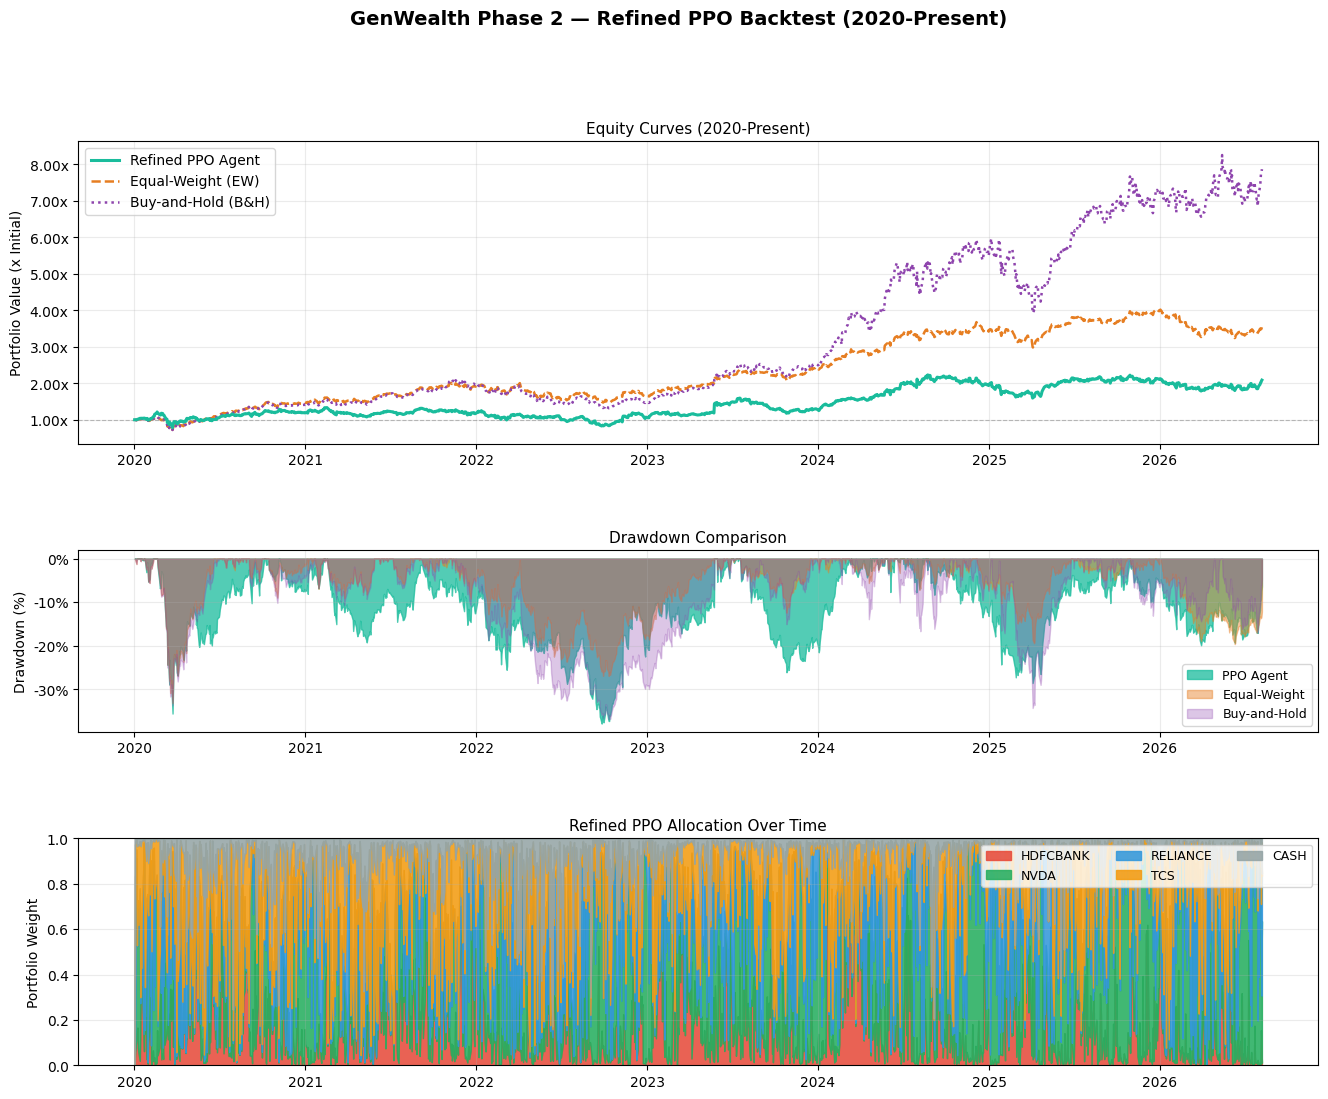

Cell 12 done: Plot saved -> ../model_artifacts\phase2_backtest_v2.png


In [12]:
# CELL 12: VISUALIZATION & COMPARISON
test_dates = test_pivot.index[:len(rl_portfolio)]

def compute_drawdown_series(portfolio):
    peak = np.maximum.accumulate(portfolio)
    return (peak - portfolio) / (peak + 1e-9)

rl_dd  = compute_drawdown_series(rl_portfolio)
eq_dd  = compute_drawdown_series(eq_portfolio)
bnh_dd = compute_drawdown_series(bnh_portfolio)

ASSET_LABELS_PLOT = [t.replace('.NS', '') for t in TICKERS] + ['CASH']
COLORS_WT = ['#E74C3C', '#27AE60', '#3498DB', '#F39C12', '#95A5A6']

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(3, 1, figure=fig, hspace=0.45, height_ratios=[2, 1.2, 1.5])
fig.suptitle("GenWealth Phase 2 — Refined PPO Backtest (2020-Present)", fontsize=14, fontweight='bold', y=0.99)

ax1 = fig.add_subplot(gs[0])
ax1.plot(test_dates, rl_portfolio  / INITIAL_BALANCE, color='#1ABC9C', linewidth=2.2, label='Refined PPO Agent', zorder=3)
ax1.plot(test_dates, eq_portfolio  / INITIAL_BALANCE, color='#E67E22', linewidth=1.8, linestyle='--', label='Equal-Weight (EW)', zorder=2)
ax1.plot(test_dates, bnh_portfolio / INITIAL_BALANCE, color='#8E44AD', linewidth=1.8, linestyle=':', label='Buy-and-Hold (B&H)', zorder=2)
ax1.axhline(1.0, color='grey', linewidth=0.8, linestyle='--', alpha=0.5)
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.2f}x'))
ax1.set_ylabel("Portfolio Value (x Initial)")
ax1.set_title("Equity Curves (2020-Present)", fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.25)

ax2 = fig.add_subplot(gs[1])
ax2.fill_between(test_dates, -rl_dd  * 100, 0, alpha=0.75, color='#1ABC9C', label='PPO Agent')
ax2.fill_between(test_dates, -eq_dd  * 100, 0, alpha=0.45, color='#E67E22', label='Equal-Weight')
ax2.fill_between(test_dates, -bnh_dd * 100, 0, alpha=0.30, color='#8E44AD', label='Buy-and-Hold')
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax2.set_ylabel("Drawdown (%)")
ax2.set_title("Drawdown Comparison", fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.25)

ax3 = fig.add_subplot(gs[2])
T_plot  = len(test_dates)
wt_plot = rl_weights[:T_plot]
bottom  = np.zeros(T_plot)
for i, (label, color) in enumerate(zip(ASSET_LABELS_PLOT, COLORS_WT)):
    ax3.fill_between(test_dates, bottom, bottom + wt_plot[:, i], label=label, color=color, alpha=0.88)
    bottom += wt_plot[:, i]
ax3.set_ylabel("Portfolio Weight")
ax3.set_title("Refined PPO Allocation Over Time", fontsize=11)
ax3.legend(loc='upper right', fontsize=9, ncol=3)
ax3.set_ylim(0, 1)
ax3.grid(True, alpha=0.25)

plt.tight_layout()
save_path = os.path.join(ART_DIR, "phase2_backtest_v2.png")
plt.savefig(save_path, dpi=140, bbox_inches='tight')
plt.show()
print(f"Cell 12 done: Plot saved -> {save_path}")

In [13]:
# CELL 13: PERFORMANCE METRICS TABLE
def annualized_sharpe(portfolio, risk_free_annual=0.0):
    daily_rets = np.diff(portfolio) / (portfolio[:-1] + 1e-9)
    excess     = daily_rets - risk_free_annual / 252
    std        = excess.std()
    return float((excess.mean() / (std + 1e-10)) * np.sqrt(252))

def max_drawdown(portfolio):
    peak = np.maximum.accumulate(portfolio)
    dd   = (peak - portfolio) / (peak + 1e-9)
    return float(dd.max())

def total_return(portfolio):
    return float((portfolio[-1] / portfolio[0]) - 1.0)

def calmar_ratio(portfolio):
    mdd = max_drawdown(portfolio)
    if mdd < 1e-9:
        return float('inf')
    years      = len(portfolio) / 252
    ann_return = (1 + total_return(portfolio)) ** (1 / max(years, 0.1)) - 1
    return float(ann_return / mdd)

strategies = {
    "PPO Agent"    : rl_portfolio,
    "Equal-Weight" : eq_portfolio,
    "Buy-and-Hold" : bnh_portfolio,
}

print("=" * 72)
print(f"  {'STRATEGY':<18} {'Total Return':>13} {'Ann. Sharpe':>12} {'Max DD':>10} {'Calmar':>10}")
print("=" * 72)
for name, pv in strategies.items():
    tr  = total_return(pv)
    sr  = annualized_sharpe(pv)
    mdd = max_drawdown(pv)
    cal = calmar_ratio(pv)
    print(f"  {name:<18} {tr*100:>12.1f}%  {sr:>11.3f}  {mdd*100:>8.1f}%  {cal:>9.3f}")
print("=" * 72)

metrics = {
    name: {
        "total_return": total_return(pv),
        "sharpe"      : annualized_sharpe(pv),
        "max_drawdown": max_drawdown(pv),
        "calmar"      : calmar_ratio(pv),
        "portfolio"   : pv.tolist(),
    }
    for name, pv in strategies.items()
}
metrics_path = os.path.join(ART_DIR, "rl_backtest_metrics_v2.pkl")
with open(metrics_path, "wb") as f:
    pickle.dump(metrics, f)
print(f"\nCell 13 done: Metrics saved -> {metrics_path}")

  STRATEGY            Total Return  Ann. Sharpe     Max DD     Calmar
  PPO Agent                 108.7%        0.538      37.8%      0.328
  Equal-Weight              254.0%        1.060      33.1%      0.673
  Buy-and-Hold              687.0%        1.203      36.8%      1.055

Cell 13 done: Metrics saved -> ../model_artifacts\rl_backtest_metrics_v2.pkl


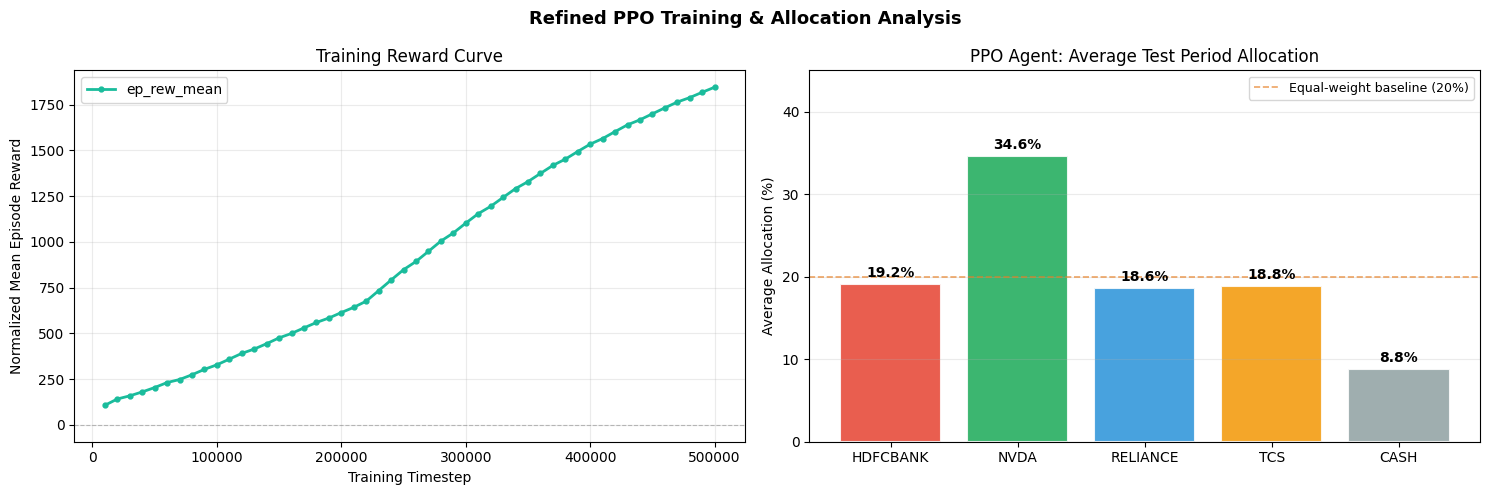

Cell 14 done: Analysis plot saved -> ../model_artifacts\ppo_training_analysis.png


In [14]:
# CELL 14: TRAINING REWARD TREND & AVERAGE ALLOCATION ANALYSIS
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Refined PPO Training & Allocation Analysis", fontsize=13, fontweight='bold')

ax_a = axes[0]
if len(callback.reward_history) >= 2:
    steps_logged = [(i + 1) * 10_000 for i in range(len(callback.reward_history))]
    ax_a.plot(steps_logged, callback.reward_history, color='#1ABC9C', linewidth=2, marker='o', markersize=3.5, label='ep_rew_mean')
    ax_a.axhline(0.0, color='grey', linewidth=0.8, linestyle='--', alpha=0.5)
    ax_a.set_xlabel("Training Timestep")
    ax_a.set_ylabel("Normalized Mean Episode Reward")
    ax_a.set_title("Training Reward Curve")
    ax_a.legend(fontsize=10)
    ax_a.grid(True, alpha=0.25)
else:
    ax_a.text(0.5, 0.5, "No reward history captured", ha='center', va='center')

ax_b = axes[1]
mean_weights = rl_weights[:len(test_dates)].mean(axis=0)
labels_clean = [t.replace('.NS', '') for t in TICKERS] + ['CASH']
colors_bar   = ['#E74C3C', '#27AE60', '#3498DB', '#F39C12', '#95A5A6']
bars = ax_b.bar(labels_clean, mean_weights * 100, color=colors_bar, edgecolor='white', linewidth=1.5, alpha=0.9)
for bar, w in zip(bars, mean_weights):
    ax_b.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, f'{w*100:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax_b.axhline(20.0, color='#E67E22', linewidth=1.2, linestyle='--', alpha=0.7, label='Equal-weight baseline (20%)')
ax_b.set_ylabel("Average Allocation (%)")
ax_b.set_title("PPO Agent: Average Test Period Allocation")
ax_b.set_ylim(0, max(mean_weights) * 130)
ax_b.legend(fontsize=9)
ax_b.grid(True, alpha=0.25, axis='y')

plt.tight_layout()
analysis_path = os.path.join(ART_DIR, "ppo_training_analysis.png")
plt.savefig(analysis_path, dpi=130, bbox_inches='tight')
plt.show()

print(f"Cell 14 done: Analysis plot saved -> {analysis_path}")